In [5]:
import json
import matplotlib.pyplot as plt

In [38]:
with open("param_sweep/sweep_results.json", "r") as file:
    sweep = json.load(file)
    
prefetch_sweep = sweep[:6]
proc_sweep = sweep[6:10]
dl_sweep = sweep[10:]

In [14]:
print(sweep[0].keys())

dict_keys(['num_proc', 'dataloader_workers', 'prefetch', 'max_rows', 'setup_time_s', 'time_to_first_row_s', 'total_time_s', 'total_rows', 'throughput_rows_per_sec'])


In [15]:
print(sweep)

[{'num_proc': 0, 'dataloader_workers': 0, 'prefetch': 1, 'max_rows': 5000, 'setup_time_s': 8.158, 'time_to_first_row_s': 1.256, 'total_time_s': 297.227, 'total_rows': 5000, 'throughput_rows_per_sec': 16.8}, {'num_proc': 0, 'dataloader_workers': 0, 'prefetch': 2, 'max_rows': 5000, 'setup_time_s': 8.249, 'time_to_first_row_s': 1.164, 'total_time_s': 274.101, 'total_rows': 5000, 'throughput_rows_per_sec': 18.2}, {'num_proc': 0, 'dataloader_workers': 0, 'prefetch': 4, 'max_rows': 5000, 'setup_time_s': 7.916, 'time_to_first_row_s': 1.183, 'total_time_s': 278.112, 'total_rows': 5000, 'throughput_rows_per_sec': 18.0}, {'num_proc': 0, 'dataloader_workers': 0, 'prefetch': 8, 'max_rows': 5000, 'setup_time_s': 8.469, 'time_to_first_row_s': 1.155, 'total_time_s': 276.588, 'total_rows': 5000, 'throughput_rows_per_sec': 18.1}, {'num_proc': 0, 'dataloader_workers': 0, 'prefetch': 12, 'max_rows': 5000, 'setup_time_s': 8.158, 'time_to_first_row_s': 1.161, 'total_time_s': 275.988, 'total_rows': 5000, 't

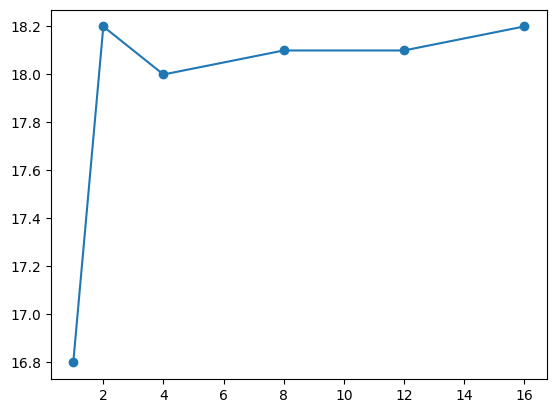

In [36]:
plt.plot(
    [s["prefetch"] for s in prefetch_sweep],
    [s["throughput_rows_per_sec"] for s in prefetch_sweep],
    "-o",
)

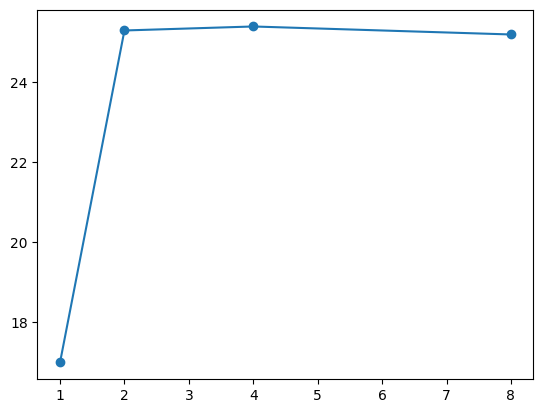

In [37]:
plt.plot(
    [s["num_proc"] for s in proc_sweep],
    [s["throughput_rows_per_sec"] for s in proc_sweep],
    "-o",
)

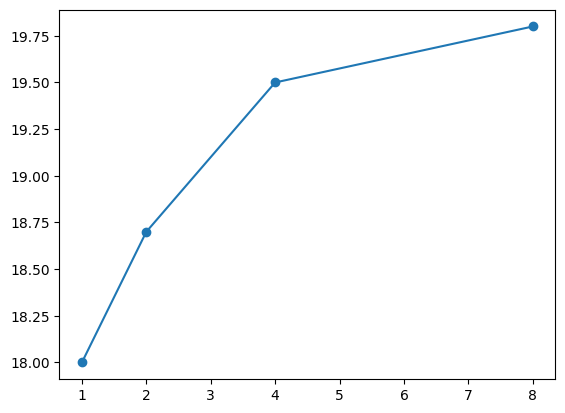

In [39]:
plt.plot(
    [s["dataloader_workers"] for s in dl_sweep],
    [s["throughput_rows_per_sec"] for s in dl_sweep],
    "-o",
)

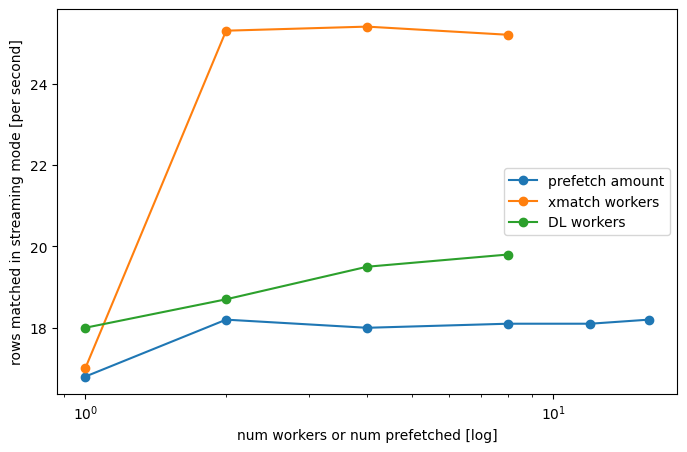

In [52]:
f, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    [s["prefetch"] for s in prefetch_sweep],
    [s["throughput_rows_per_sec"] for s in prefetch_sweep],
    "-o",
    label="prefetch amount",
)
ax.plot(
    [s["num_proc"] for s in proc_sweep],
    [s["throughput_rows_per_sec"] for s in proc_sweep],
    "-o",
    label="xmatch workers",
)
ax.plot(
    [s["dataloader_workers"] for s in dl_sweep],
    [s["throughput_rows_per_sec"] for s in dl_sweep],
    "-o",
    label="DL workers",
)
ax.set_xscale("log")
ax.set_ylabel("rows matched in streaming mode [per second]")
ax.set_xlabel("num workers or num prefetched [log]")
ax.legend()